In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


# Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

from warnings import filterwarnings
filterwarnings("ignore")

2026-02-03 08:01:15.485582: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770105675.779455      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770105675.862165      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770105676.651214      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770105676.651301      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770105676.651305      17 computation_placer.cc:177] computation placer alr

# Load Dataset

In [3]:
train=pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
test=pd.read_csv("/kaggle/input/digit-recognizer/test.csv")

# Explore Datasets

In [4]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (42000, 785)
Test shape: (28000, 784)


In [5]:
train_labels=train["label"]
train_labels.head()

0    1
1    0
2    1
3    4
4    0
Name: label, dtype: int64

In [6]:
print(len(train))
print(len(test))

42000
28000


# Visualization

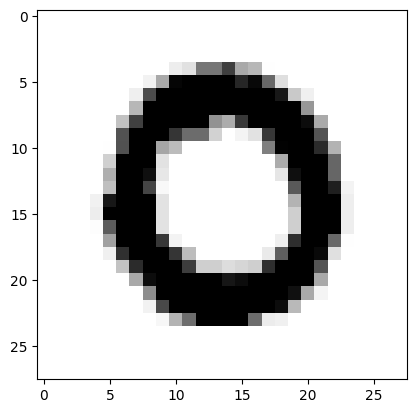

In [7]:
plt.imshow(train.iloc[1, 1:].values.reshape(28, 28), cmap=plt.cm.binary)

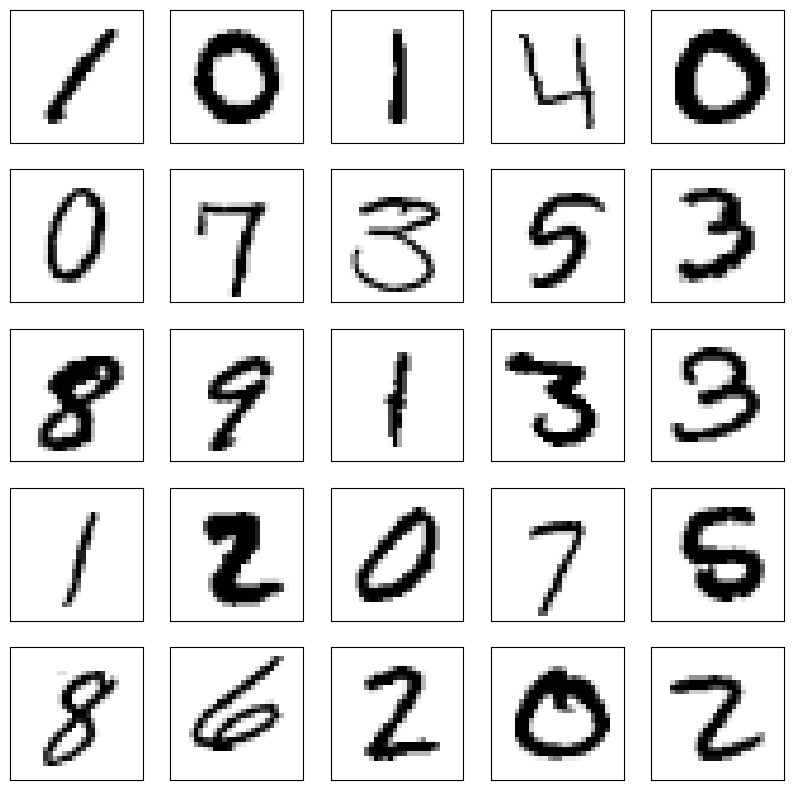

In [8]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # get the pixel values for the i-th row (skip the 'label' column) and reshape to 28x28
    pixels = train.iloc[i, 1:].values.reshape(28,28)
    plt.imshow(pixels, cmap=plt.cm.binary)
plt.show()

# Pixel Values

In [9]:
print("pixel values")
# use the already-defined `pixels` ndarray (28x28) instead of indexing DataFrame by 0
for row in pixels:
    for pixel in row:
        print("{:3}".format(pixel), end=" ")
    print()

pixel values
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0  34 107 107 107 107 184 240 178 107 107  17   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0  45 149 226 235 252 252 252 252 252 252 253 252 252 230 166   0   0   0   0   0   0   0   0   0 
  0   0   0   0 233 252 252 252 252 252 252 252 205 172 173 206 252 252 206  21   0

# Feature Selection

In [10]:
x=train.drop("label",axis=1)
y=train["label"]

# Data Split

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Normalize

In [12]:
# Normalize and reshape the splits
x_train = x_train.values.astype('float32') / 255.0
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))

x_test = x_test.values.astype('float32') / 255.0
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

# Model

In [13]:
from tensorflow.keras import layers

model = tf.keras.Sequential([
    layers.InputLayer(input_shape=(28,28,1)),
    
    layers.Conv2D(filters=10, kernel_size=(3,3), activation="relu"),
    layers.Conv2D(filters=10, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(filters=20, kernel_size=(3,3), activation="relu"),
    layers.Conv2D(filters=20, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Flatten(),
    layers.Dense(100, activation="softmax"),
])

2026-02-03 08:01:40.760619: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Model Summary

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 20)     │         1,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 20)       │         3,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        32,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,550 (150.59 KB)

 Trainable params: 38,550 (150.59 KB)

 Non-trainable params: 0 (0.00 B)

# Compile model

In [15]:
model.compile(optimizer="adam",
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"])

# Fit model

In [16]:
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/5
525/525 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.6337 - loss: 1.3202 - val_accuracy: 0.9438 - val_loss: 0.1880
Epoch 2/5
525/525 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.9573 - loss: 0.1407 - val_accuracy: 0.9661 - val_loss: 0.1066
Epoch 3/5
525/525 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.9704 - loss: 0.0963 - val_accuracy: 0.9721 - val_loss: 0.0888
Epoch 4/5
525/525 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.9764 - loss: 0.0776 - val_accuracy: 0.9765 - val_loss: 0.0736
Epoch 5/5
525/525 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.9812 - loss: 0.0605 - val_accuracy: 0.9808 - val_loss: 0.0631


# Model Evaluation

In [17]:
loss,accuracy=model.evaluate(x_test,y_test)
print(f"Test loss: {loss:.3f}")
print(f"Test accuracy: {accuracy:.2f}")

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9790 - loss: 0.0694
Test loss: 0.063
Test accuracy: 0.98


# Test Data Prediction

In [18]:
# Normalize and reshape the test data for prediction
x_test_prediction = test.values.astype('float32') / 255.0
x_test_prediction = x_test_prediction.reshape((x_test_prediction.shape[0], 28, 28, 1))

# Make predictions with the preprocessed test data
result = model.predict(x_test_prediction)

875/875 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step


In [19]:
simple_submission=pd.DataFrame({"Label":result.argmax(axis=1)})

simple_submission.index.name="ImageId"
simple_submission.index+=1

In [20]:
simple_submission.head()

,Label
ImageId,
1,2
2,0
3,9
4,9
5,3


# Thanks!